In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir("/content/drive/MyDrive/ML_Safety"))

['test.zip', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'validation.zip', 'train.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


In [3]:
!unzip -q "/content/drive/MyDrive/ML_Safety/test.zip" -d "/content/test"
!unzip -q "/content/drive/MyDrive/ML_Safety/test-fog.zip" -d "/content/test-fog"
!unzip -q "/content/drive/MyDrive/ML_Safety/test-night.zip" -d "/content/test-night"
!unzip -q "/content/drive/MyDrive/ML_Safety/test-town-01.zip" -d "/content/test-town"

In [4]:
import os

print("TEST:")
print(os.listdir("/content/test"))

print("\nFOG:")
print(os.listdir("/content/test-fog"))

print("\nNIGHT:")
print(os.listdir("/content/test-night"))

print("\nTOWN:")
print(os.listdir("/content/test-town"))

TEST:
['test']

FOG:
['test-fog']

NIGHT:
['test-night']

TOWN:
['test-town-01']


In [5]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset

In [6]:
class DrivingDataset224(Dataset):

    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_folder = image_folder
        self.labels_df = labels_df
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):

        frame = self.labels_df.iloc[idx]["frame"]

        image_path = os.path.join(
            self.image_folder,
            f"{frame}.png"
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels_df.iloc[idx][self.target_column]

        return image, label

In [26]:
transform_224 = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [9]:
import pandas as pd

labels_df_test = pd.read_csv(
    "/content/test/test/labels.csv"
)

print(labels_df_test.shape)
labels_df_test.head()

(3600, 7)


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


In [10]:
import os

image_folder = "/content/test/test/rgb-front"

files = sorted(os.listdir(image_folder))

print("Total images:", len(files))
print(files[:5])

Total images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


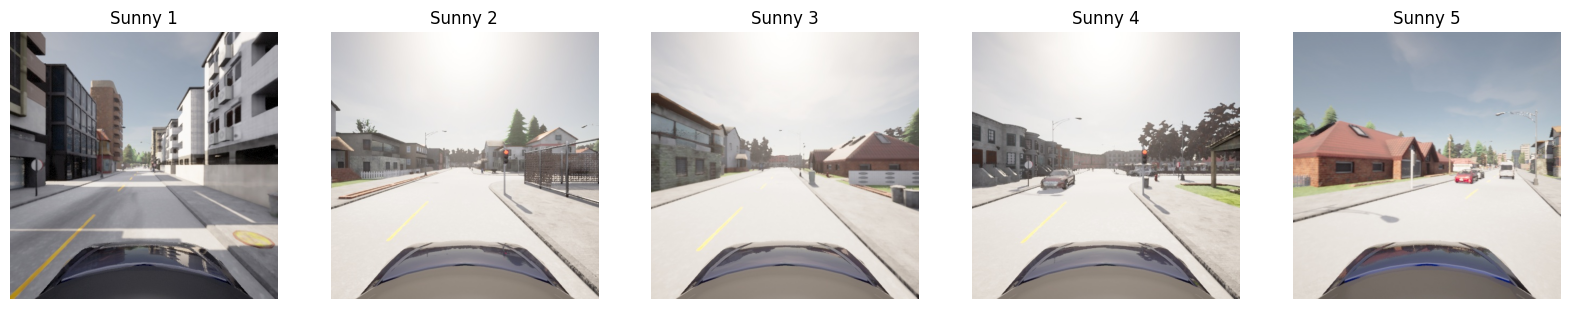

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

indices = [0, 100, 500, 1000, 1500]

for i, idx in enumerate(indices):

    image = Image.open(
        image_folder + "/" + files[idx]
    )

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Sunny {i+1}")

plt.show()

In [12]:
import os

fog_folder = "/content/test-fog/test-fog/rgb-front"

fog_files = sorted(os.listdir(fog_folder))

print("Fog images:", len(fog_files))
print(fog_files[:5])

Fog images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


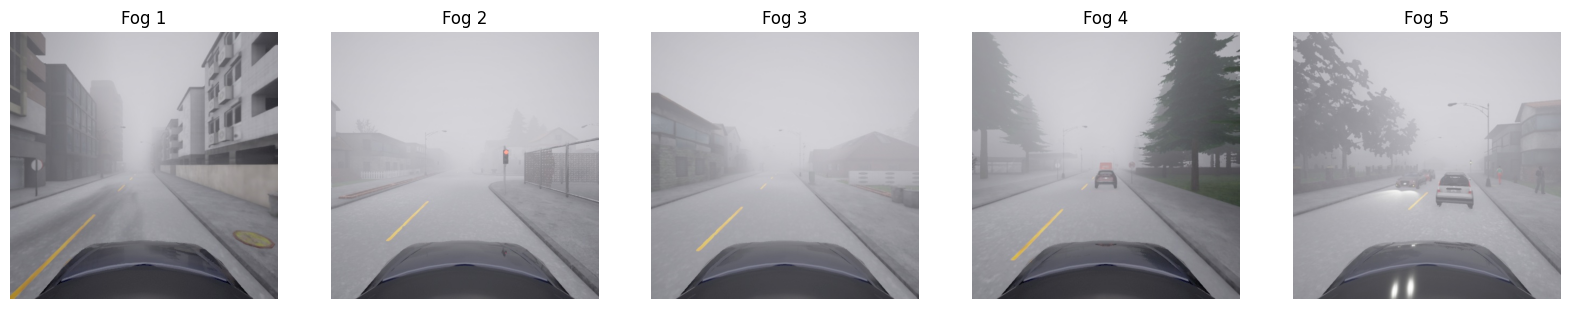

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

indices = [0, 100, 500, 1000, 1500]

for i, idx in enumerate(indices):

    image = Image.open(
        fog_folder + "/" + fog_files[idx]
    )

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Fog {i+1}")

plt.show()

In [14]:
import os

night_folder = "/content/test-night/test-night/rgb-front"

night_files = sorted(os.listdir(night_folder))

print("Night images:", len(night_files))
print(night_files[:5])

Night images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


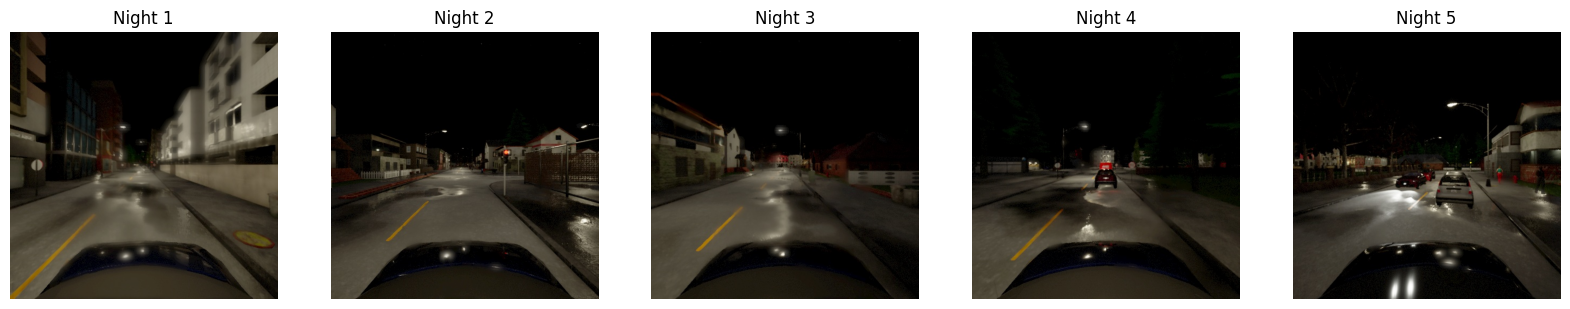

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

indices = [0, 100, 500, 1000, 1500]

for i, idx in enumerate(indices):

    image = Image.open(
        night_folder + "/" + night_files[idx]
    )

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Night {i+1}")

plt.show()

In [16]:
import os

town_folder = "/content/test-town/test-town-01/rgb-front"

town_files = sorted(os.listdir(town_folder))

print("Town images:", len(town_files))
print(town_files[:5])

Town images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


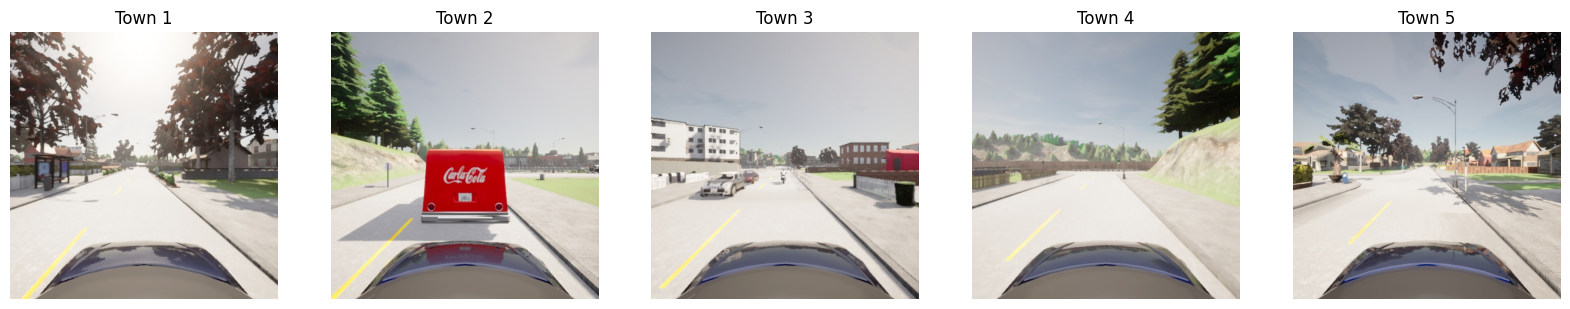

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

indices = [0, 100, 500, 1000, 1500]

for i, idx in enumerate(indices):

    image = Image.open(
        town_folder + "/" + town_files[idx]
    )

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Town {i+1}")

plt.show()

In [18]:
import torch

print(torch.load("/content/drive/MyDrive/ML_Safety/traffic_light_model.pth",
                 map_location="cpu").keys())

odict_keys(['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.10.weight', 'model.10.bias', 'model.12.weight', 'model.12.bias'])


In [19]:
import torch

state_dict = torch.load(
    "/content/drive/MyDrive/ML_Safety/traffic_light_model.pth",
    map_location="cpu"
)

for k, v in state_dict.items():
    print(k, v.shape)

model.0.weight torch.Size([16, 3, 3, 3])
model.0.bias torch.Size([16])
model.3.weight torch.Size([32, 16, 3, 3])
model.3.bias torch.Size([32])
model.6.weight torch.Size([64, 32, 3, 3])
model.6.bias torch.Size([64])
model.10.weight torch.Size([128, 50176])
model.10.bias torch.Size([128])
model.12.weight torch.Size([1, 128])
model.12.bias torch.Size([1])


In [22]:
import torch
import torch.nn as nn

traffic_light_model = nn.Sequential(

    nn.Conv2d(3,16,3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16,32,3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32,64,3),
    nn.ReLU(),

    nn.Flatten(),
    nn.Identity(),

    nn.Linear(50176,128),
    nn.ReLU(),

    nn.Linear(128,1)
)

state_dict = torch.load(
    "/content/drive/MyDrive/ML_Safety/traffic_light_model.pth",
    map_location="cpu"
)

new_state_dict = {}

for k, v in state_dict.items():
    new_key = k.replace("model.", "")
    new_state_dict[new_key] = v

traffic_light_model.load_state_dict(new_state_dict)

traffic_light_model.eval()

print("SUCCESS")

SUCCESS


In [24]:
print(traffic_light_model)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Identity()
  (10): Linear(in_features=50176, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=1, bias=True)
)


In [25]:
img = Image.open(image_folder + "/" + files[0]).convert("RGB")

x = transform_224(img)
x = x.unsqueeze(0)

print("Input shape:", x.shape)

with torch.no_grad():

    x1 = traffic_light_model[0](x)
    print("After Conv1:", x1.shape)

    x2 = traffic_light_model[1](x1)
    x2 = traffic_light_model[2](x2)
    print("After Pool1:", x2.shape)

    x3 = traffic_light_model[3](x2)
    x3 = traffic_light_model[4](x3)
    x3 = traffic_light_model[5](x3)
    print("After Pool2:", x3.shape)

    x4 = traffic_light_model[6](x3)
    print("After Conv3:", x4.shape)

    print("Flatten size:", x4.numel())

Input shape: torch.Size([1, 3, 224, 224])
After Conv1: torch.Size([1, 16, 222, 222])
After Pool1: torch.Size([1, 16, 111, 111])
After Pool2: torch.Size([1, 32, 54, 54])
After Conv3: torch.Size([1, 64, 52, 52])
Flatten size: 173056


In [27]:
img = Image.open(image_folder + "/" + files[0]).convert("RGB")

x = transform_224(img)
x = x.unsqueeze(0)

with torch.no_grad():
    pred = traffic_light_model(x)

print(pred)

tensor([[-3.9919]])


In [28]:
import torch

img = Image.open(image_folder + "/" + files[0]).convert("RGB")

x = transform_224(img)
x = x.unsqueeze(0)

with torch.no_grad():
    pred = traffic_light_model(x)

score = torch.sigmoid(pred).item()

print("Raw output:", pred.item())
print("Probability:", score)

Raw output: -3.9919354915618896
Probability: 0.01812920533120632


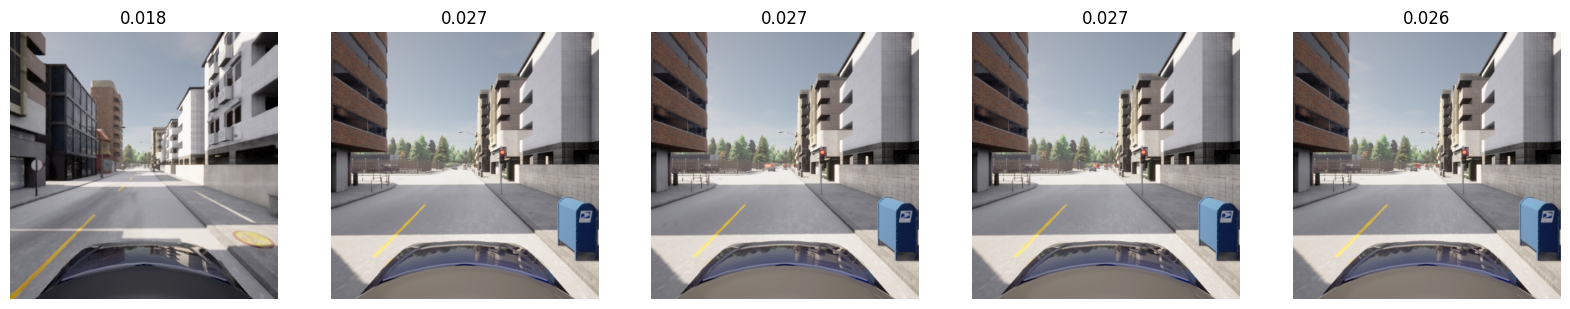

In [29]:
plt.figure(figsize=(20,8))

for i in range(5):

    img = Image.open(
        image_folder + "/" + files[i]
    ).convert("RGB")

    x = transform_224(img)
    x = x.unsqueeze(0)

    with torch.no_grad():
        pred = traffic_light_model(x)

    score = torch.sigmoid(pred).item()

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"{score:.3f}")
    plt.axis("off")

plt.show()

In [30]:
import torch
import numpy as np
from PIL import Image

def get_scores(folder, file_list, model):
    scores = []

    for f in file_list[:500]:   # use first 500 images for speed
        img = Image.open(folder + "/" + f).convert("RGB")

        x = transform_224(img)
        x = x.unsqueeze(0)

        with torch.no_grad():
            pred = model(x)

        score = torch.sigmoid(pred).item()
        scores.append(score)

    return scores

In [31]:
sunny_scores = get_scores(image_folder, files, traffic_light_model)

fog_scores = get_scores(fog_folder, fog_files, traffic_light_model)

night_scores = get_scores(night_folder, night_files, traffic_light_model)

town_scores = get_scores(town_folder, town_files, traffic_light_model)

print("Sunny:", len(sunny_scores))
print("Fog:", len(fog_scores))
print("Night:", len(night_scores))
print("Town:", len(town_scores))

Sunny: 500
Fog: 500
Night: 500
Town: 500


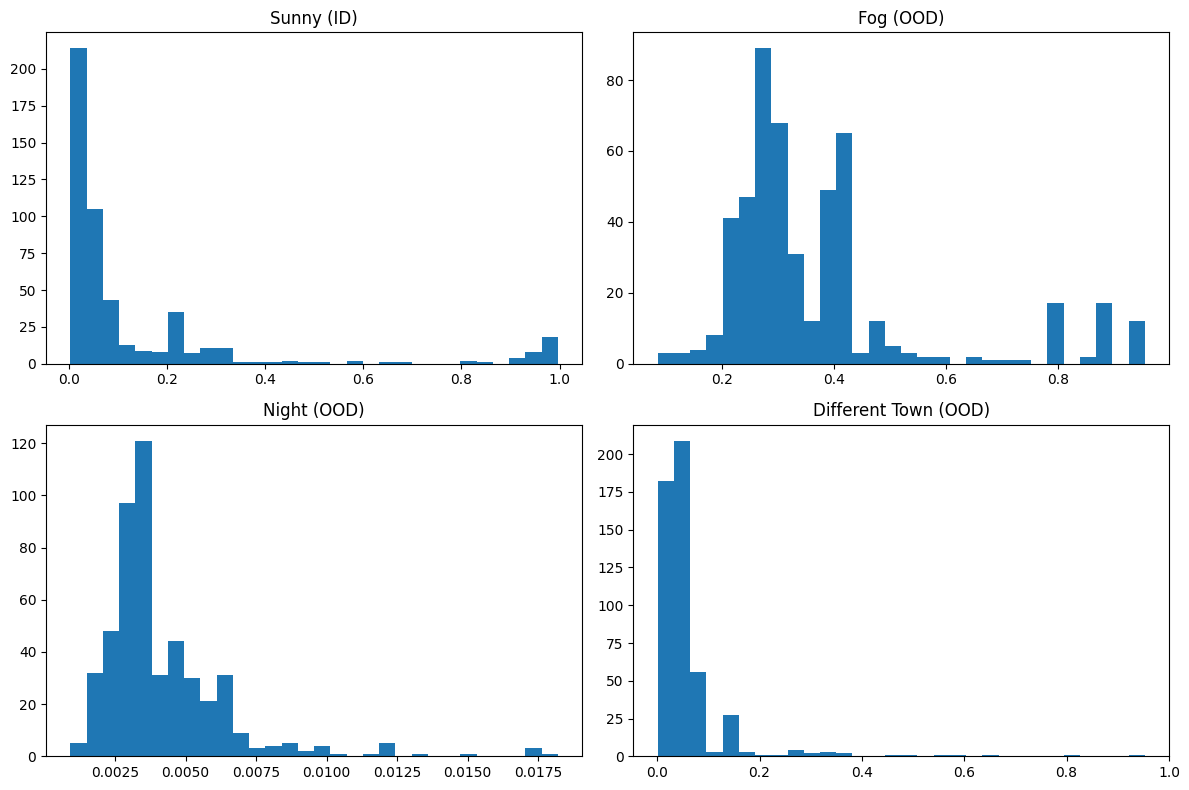

In [34]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,2, figsize=(12,8))

axs[0,0].hist(sunny_scores, bins=30)
axs[0,0].set_title("Sunny (ID)")

axs[0,1].hist(fog_scores, bins=30)
axs[0,1].set_title("Fog (OOD)")

axs[1,0].hist(night_scores, bins=30)
axs[1,0].set_title("Night (OOD)")

axs[1,1].hist(town_scores, bins=30)
axs[1,1].set_title("Different Town (OOD)")

plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score
import numpy as np

id_scores = np.array(sunny_scores)

ood_scores = np.concatenate([
    fog_scores,
    night_scores,
    town_scores
])

labels = np.concatenate([
    np.zeros(len(id_scores)),      # ID
    np.ones(len(ood_scores))       # OOD
])

scores = np.concatenate([
    id_scores,
    ood_scores
])

# low confidence = OOD
auroc = roc_auc_score(labels, -scores)

print("MSP AUROC =", auroc)

MSP AUROC = 0.5582733333333333


In [36]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import torch

def extract_features(folder, file_list, model):
    feats = []

    for f in file_list[:300]:
        img = Image.open(folder + "/" + f).convert("RGB")

        x = transform_224(img)
        x = x.unsqueeze(0)

        with torch.no_grad():
            feat = model[:9](x)
            feat = feat.view(-1).numpy()

        feats.append(feat)

    return np.array(feats)

train_feats = extract_features(
    image_folder,
    files,
    traffic_light_model
)

fog_feats = extract_features(
    fog_folder,
    fog_files,
    traffic_light_model
)

night_feats = extract_features(
    night_folder,
    night_files,
    traffic_light_model
)

town_feats = extract_features(
    town_folder,
    town_files,
    traffic_light_model
)

print(train_feats.shape)

(300, 50176)


In [37]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Fit kNN on ID features
knn = NearestNeighbors(n_neighbors=1)
knn.fit(train_feats)

# Distance = OOD score
id_dist, _ = knn.kneighbors(train_feats)
fog_dist, _ = knn.kneighbors(fog_feats)
night_dist, _ = knn.kneighbors(night_feats)
town_dist, _ = knn.kneighbors(town_feats)

id_scores_knn = id_dist.flatten()

ood_scores_knn = np.concatenate([
    fog_dist.flatten(),
    night_dist.flatten(),
    town_dist.flatten()
])

labels = np.concatenate([
    np.zeros(len(id_scores_knn)),
    np.ones(len(ood_scores_knn))
])

scores = np.concatenate([
    id_scores_knn,
    ood_scores_knn
])

from sklearn.metrics import roc_auc_score

auroc_knn = roc_auc_score(labels, scores)

print("kNN AUROC =", auroc_knn)

kNN AUROC = 1.0
